In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Academic plot styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

In [17]:
BASE_DIR = "./logs"

MODELS_PATHS = {
    "Small": os.path.join(BASE_DIR, "model_track_01_Small_400000steps_buf50000", "20260324_194026"),
    "Base":  os.path.join(BASE_DIR, "model_track_01_Base_400000steps_buf50000", "20260325_192331"),
    "Large": os.path.join(BASE_DIR, "model_track_01_Large_400000steps_buf50000", "20260326_203022")
}

TAGS_REWARD = ['Collector/Episode_Return_Mean_50']
TAGS_LOSS = ['Training_Loss/Critic_Loss']

In [18]:
def extract_tb_data(log_dir, possible_tags):
    if not os.path.exists(log_dir):
        print(f"[WARNING] Directory not found: {log_dir}")
        return pd.DataFrame()
        
    try:
        event_acc = EventAccumulator(log_dir, size_guidance={'scalars': 0})
        event_acc.Reload()
        
        available_tags = event_acc.Tags().get('scalars', [])
        
        target_tag = next((tag for tag in possible_tags if tag in available_tags), None)
                
        if not target_tag:
            print(f"[ERROR] None of the tags {possible_tags} found in {log_dir}")
            return pd.DataFrame()
            
        events = event_acc.Scalars(target_tag)
        
        df = pd.DataFrame([(e.step, e.value) for e in events], columns=['Step', 'Value'])
        return df
        
    except Exception as e:
        print(f"[ERROR] Failed to read {log_dir}: {e}")
        return pd.DataFrame()

def process_data(models_dict, subfolder, tags, window=50):
    """Aggregates and smooths data for all specified models."""
    all_data = []
    
    for model_name, base_path in models_dict.items():
        full_path = os.path.join(base_path, subfolder)
        df = extract_tb_data(full_path, tags)
        
        if not df.empty:
            df['Model'] = model_name
            df['Value_Smoothed'] = df['Value'].rolling(window=window, min_periods=1).mean()
            df['Value_Std'] = df['Value'].rolling(window=window, min_periods=1).std()
            all_data.append(df)
            
    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

In [19]:
print("Extracting TensorBoard logs (this might take a moment)...")

df_reward = process_data(MODELS_PATHS, "collector", TAGS_REWARD, window=50)
df_loss = process_data(MODELS_PATHS, "learner", TAGS_LOSS, window=100)

print("Data extraction complete! Data is now in memory.")

Extracting TensorBoard logs (this might take a moment)...
Data extraction complete! Data is now in memory.


Zapisano wykres nagrody do: eval/plots\learning_curve_reward.png


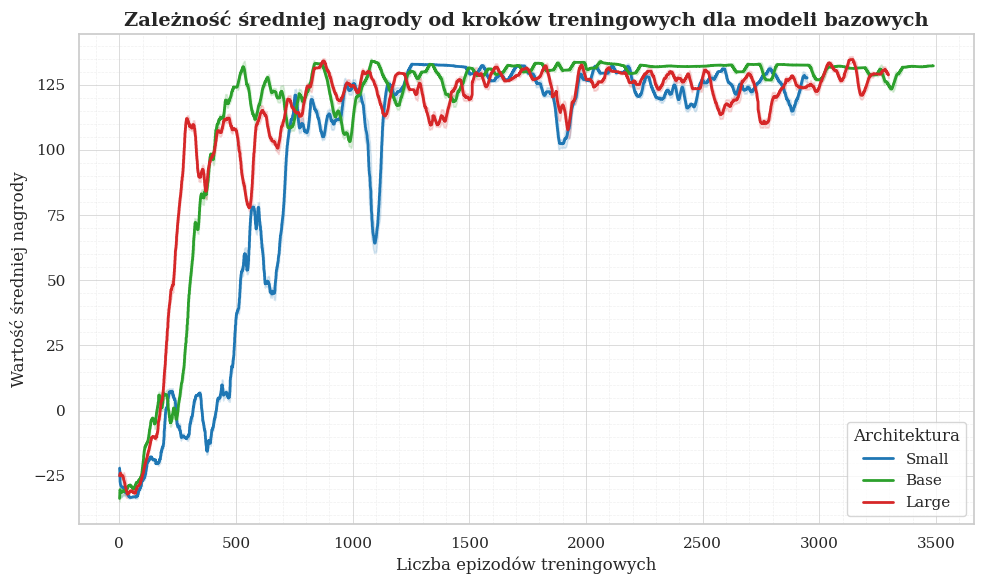

Zapisano wykres straty do: eval/plots\training_loss.png


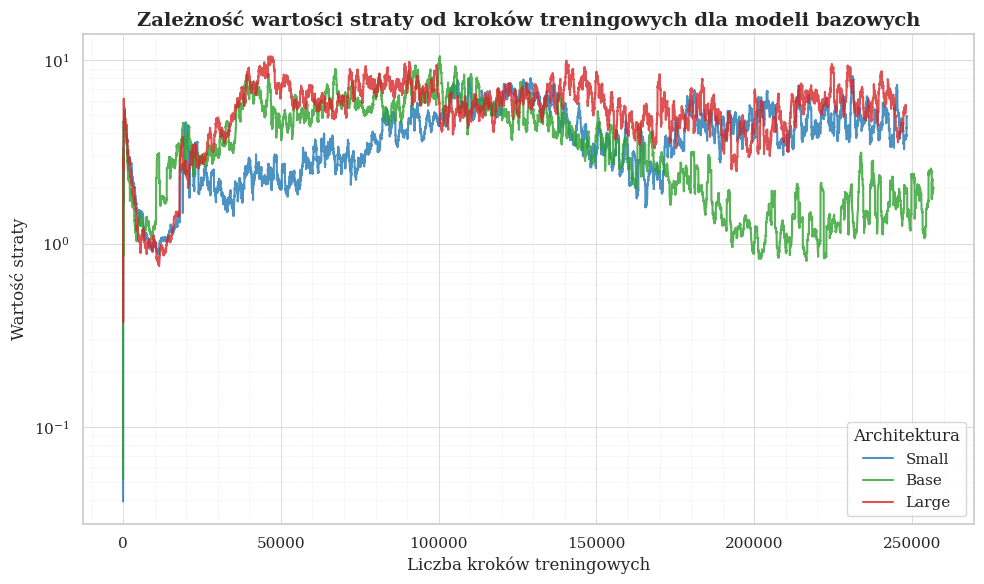

In [20]:
#4.2
import os

OUTPUT_DIR = "eval/plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

colors = {'Small': '#1f77b4', 'Base': '#2ca02c', 'Large': '#d62728'} 

if not df_reward.empty:
    plt.figure(figsize=(10, 6))
    
    for model in ['Small', 'Base', 'Large']:
        subset = df_reward[df_reward['Model'] == model]
        if not subset.empty:
            plt.plot(subset['Step'], subset['Value_Smoothed'], label=model, color=colors[model], linewidth=2)
            plt.fill_between(subset['Step'], 
                             subset['Value_Smoothed'] - subset['Value_Std'], 
                             subset['Value_Smoothed'] + subset['Value_Std'], 
                             color=colors[model], alpha=0.15)

    plt.title('Zależność średniej nagrody od kroków treningowych dla modeli bazowych', fontsize=14, fontweight='bold')
    plt.xlabel('Liczba epizodów treningowych', fontsize=12)
    plt.ylabel('Wartość średniej nagrody', fontsize=12)
    plt.legend(title="Architektura", loc="lower right")
    
    plt.minorticks_on()
    plt.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.7)
    plt.grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.3)
    
    plt.tight_layout()
    
    save_path = os.path.join(OUTPUT_DIR, 'learning_curve_reward.png')
    plt.savefig(save_path, dpi=300)
    print(f"Zapisano wykres nagrody do: {save_path}")
    
    plt.show()
else:
    print("No reward data found to plot.")


if not df_loss.empty:
    plt.figure(figsize=(10, 6))
    
    for model in ['Small', 'Base', 'Large']:
        subset = df_loss[df_loss['Model'] == model]
        if not subset.empty:
            plt.plot(subset['Step'], subset['Value_Smoothed'], label=model, color=colors[model], linewidth=1.5, alpha=0.8)

    plt.title('Zależność wartości straty od kroków treningowych dla modeli bazowych', fontsize=14, fontweight='bold')
    plt.xlabel('Liczba kroków treningowych', fontsize=12)
    plt.ylabel('Wartość straty', fontsize=12)
    
    plt.yscale('log')
    plt.legend(title="Architektura", loc="lower right")
    
    plt.minorticks_on()
    plt.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.7)
    plt.grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.3)
    
    plt.tight_layout()
    
    save_path = os.path.join(OUTPUT_DIR, 'training_loss.png')
    plt.savefig(save_path, dpi=300)
    print(f"Zapisano wykres straty do: {save_path}")
    
    plt.show()
else:
    print("No loss data found to plot.")

In [21]:
#4.3
MODELS_ALL_PATHS = {
    "Small (bazowy)": os.path.join(BASE_DIR, "model_track_01_Small_400000steps_buf50000", "20260324_194026"),
    "Base (bazowy)":  os.path.join(BASE_DIR, "model_track_01_Base_400000steps_buf50000", "20260325_192331"),
    "Large (bazowy)": os.path.join(BASE_DIR, "model_track_01_Large_400000steps_buf50000", "20260326_203022"),
    "Small (wielozadaniowy)": os.path.join(BASE_DIR, "model_mix_track_01_06Small_800000steps_buf50000", "20260402_204953"),
    "Base (wielozadaniowy)":  os.path.join(BASE_DIR, "model_mix_track_01_06Base_800000steps_buf50000", "20260328_152125"),
    "Large (wielozadaniowy)": os.path.join(BASE_DIR, "model_mix_track_01_06Large_800000steps_buf50000", "20260403_203452")
}

df_all_reward = process_data(MODELS_ALL_PATHS, "collector", ['Collector/Episode_Return_Mean_50'], window=100)

MODELS_MIX_ONLY = {k: v for k, v in MODELS_ALL_PATHS.items() if "(wielozadaniowy)" in k}
df_mix_loss = process_data(MODELS_MIX_ONLY, "learner", ['Training_Loss/Critic_Loss'], window=100)

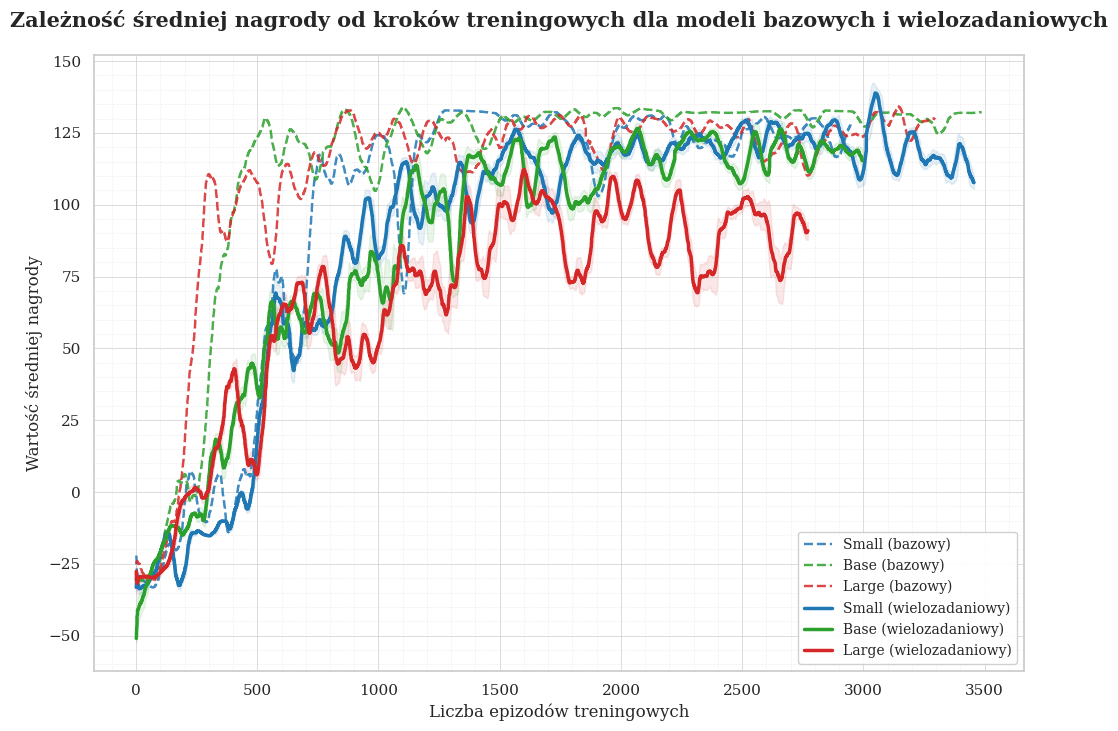

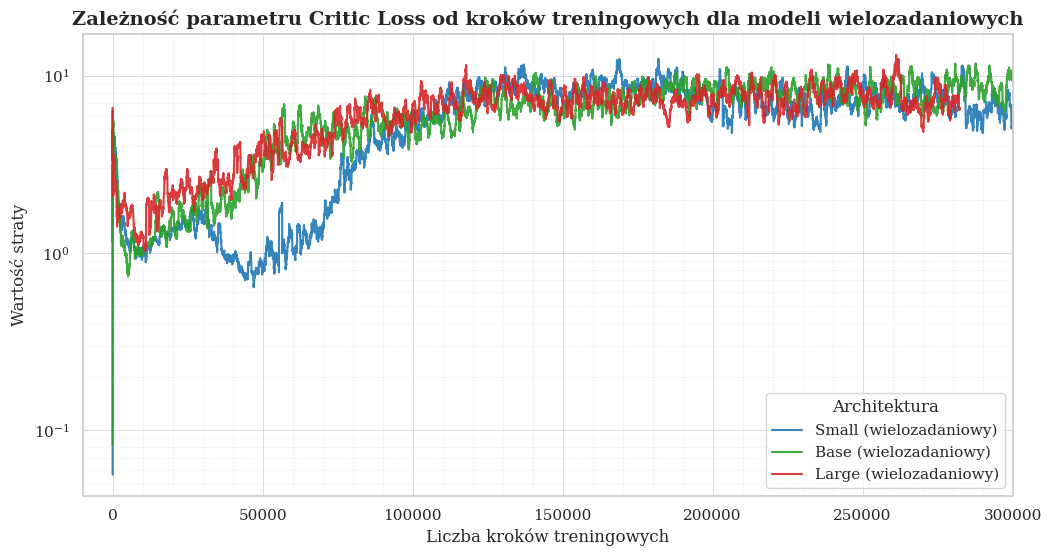

In [22]:

if not df_all_reward.empty:
    plt.figure(figsize=(12, 8))
    
    color_map = {
        'Small (bazowy)': '#1f77b4', 'Small (wielozadaniowy)': '#1f77b4',
        'Base (bazowy)': '#2ca02c', 'Base (wielozadaniowy)': '#2ca02c',
        'Large (bazowy)': '#d62728', 'Large (wielozadaniowy)': '#d62728'
    }
    
    for model in MODELS_ALL_PATHS.keys():
        subset = df_all_reward[df_all_reward['Model'] == model]
        if not subset.empty:
            is_baseline = '(bazowy)' in model
            style = '--' if is_baseline else '-'
            alpha_val = 0.85 if is_baseline else 1.0
            lw = 1.75 if is_baseline else 2.5
            
            plt.plot(subset['Step'], subset['Value_Smoothed'], 
                     label=model, color=color_map[model],
                     linestyle=style, linewidth=lw, alpha=alpha_val)
            
            if '(wielozadaniowy)' in model:
                plt.fill_between(subset['Step'], 
                                 subset['Value_Smoothed'] - subset['Value_Std'], 
                                 subset['Value_Smoothed'] + subset['Value_Std'], 
                                 color=color_map[model], alpha=0.1)

    plt.title('Zależność średniej nagrody od kroków treningowych dla modeli bazowych i wielozadaniowych', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Liczba epizodów treningowych', fontsize=12)
    plt.ylabel('Wartość średniej nagrody', fontsize=12)
    plt.legend(loc='lower right', fontsize=10, frameon=True, framealpha=0.9)
    plt.minorticks_on()
    plt.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.7)
    plt.grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, 'baseline_vs_mix_reward.png'), dpi=300, bbox_inches='tight')
    plt.show()

if not df_mix_loss.empty:
    plt.figure(figsize=(12, 6))
    mix_colors = {'Small (wielozadaniowy)': '#1f77b4', 'Base (wielozadaniowy)': '#2ca02c', 'Large (wielozadaniowy)': '#d62728'}
    
    for model in mix_colors.keys():
        subset = df_mix_loss[df_mix_loss['Model'] == model]
        if not subset.empty:
            plt.plot(subset['Step'], subset['Value_Smoothed'], 
                     label=model, color=mix_colors[model], linewidth=1.5, alpha=0.9)

    plt.title('Zależność parametru Critic Loss od kroków treningowych dla modeli wielozadaniowych', fontsize=14, fontweight='bold')
    plt.xlabel('Liczba kroków treningowych', fontsize=12)
    plt.xlim(-10000, 300000)
    plt.ylabel('Wartość straty', fontsize=12)
    plt.yscale('log')
    plt.legend(title="Architektura", loc="lower right")
    plt.minorticks_on()
    plt.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.7)
    plt.grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, 'mix_loss_fluctuations.png'), dpi=300, bbox_inches='tight')
    plt.show()

C:\Users\kkucz\AppData\Local\Temp\ipykernel_6208\78572153.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_finished['Test_Name'] = pd.Categorical(df_finished['Test_Name'], categories=desired_order, ordered=True)


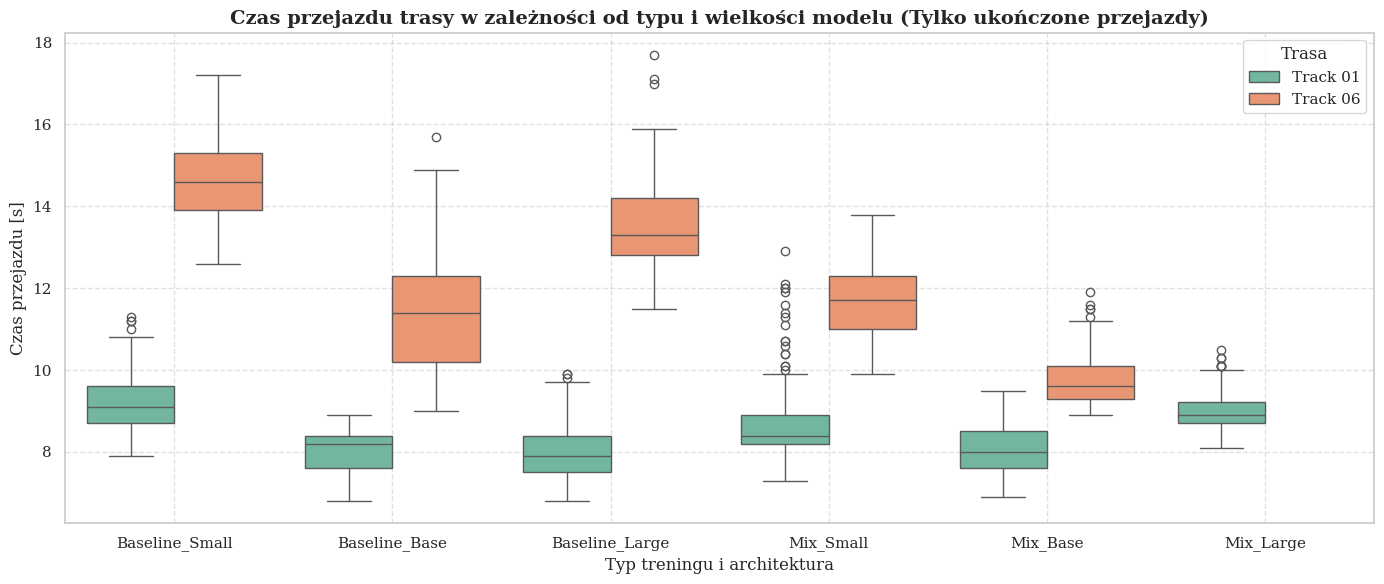

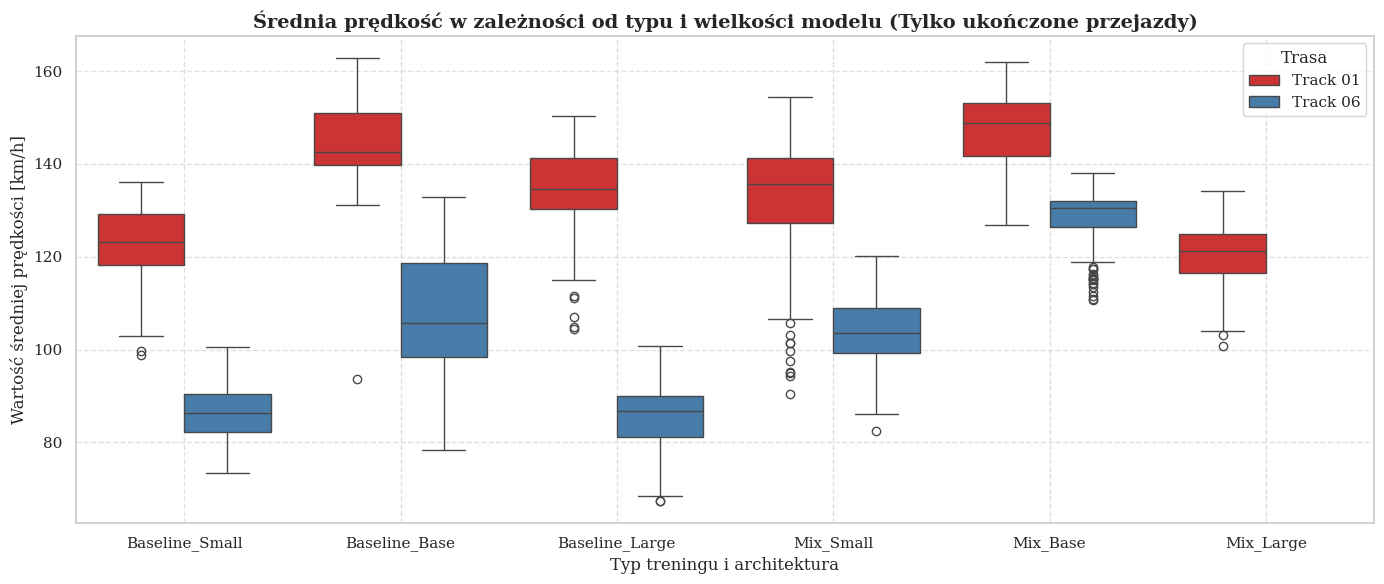

C:\Users\kkucz\AppData\Local\Temp\ipykernel_6208\78572153.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  completion_rates = df.groupby(['Track', 'Test_Name'])['Status'].apply(lambda x: (x == 'WIN').mean() * 100).reset_index()


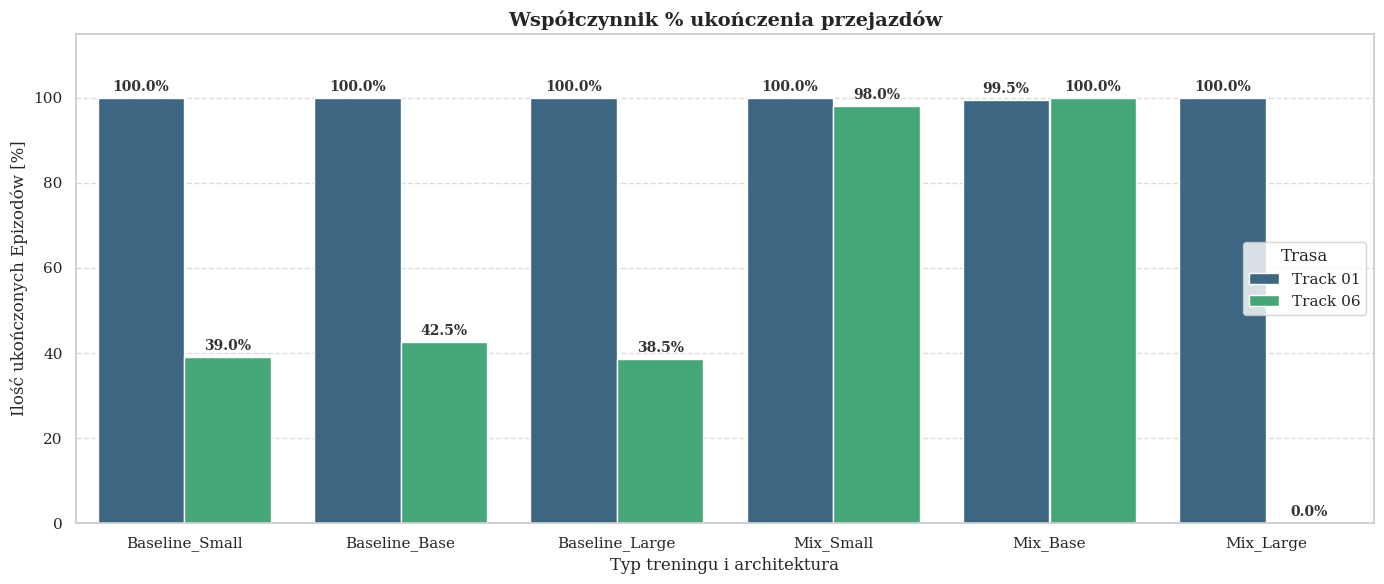

In [23]:
# 4.3.4
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

TRACK_01_CSV = r"eval\raw_matrix_20260405_203355_track01.csv"
TRACK_06_CSV = r"eval\raw_matrix_20260410_203937_track06.csv"
OUTPUT_DIR = "eval/plots"

os.makedirs(OUTPUT_DIR, exist_ok=True)

df1 = pd.read_csv(TRACK_01_CSV)
df1['Track'] = 'Track 01'
df2 = pd.read_csv(TRACK_06_CSV)
df2['Track'] = 'Track 06'

df = pd.concat([df1, df2], ignore_index=True)
df = df[~df['Test_Name'].str.contains("forgetting|Forgetting", case=False, na=False)]

TMRL_ENV_HZ = 10.0 
df['Real_InGame_Time'] = df['Steps'] / TMRL_ENV_HZ

df_finished = df[df['Status'] == 'WIN']

desired_order = [
    'Baseline_Small', 'Baseline_Base', 'Baseline_Large',
    'Mix_Small', 'Mix_Base', 'Mix_Large'
]

df_finished['Test_Name'] = pd.Categorical(df_finished['Test_Name'], categories=desired_order, ordered=True)
df['Test_Name'] = pd.Categorical(df['Test_Name'], categories=desired_order, ordered=True)

plt.figure(figsize=(14, 6))
ax1 = sns.boxplot(data=df_finished, x='Test_Name', y='Real_InGame_Time', hue='Track', palette='Set2')
plt.title('Czas przejazdu trasy w zależności od typu i wielkości modelu (Tylko ukończone przejazdy)', fontsize=14, fontweight='bold')
plt.xlabel('Typ treningu i architektura', fontsize=12)
plt.ylabel('Czas przejazdu [s]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
if ax1.legend_:
    ax1.legend_.set_title('Trasa')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_real_ingame_time_boxplot.png'), dpi=300)
plt.show()

df_finished = df_finished.copy()
df_finished['Avg_Speed_kmh'] = df_finished['Avg_Speed'] * 3.6

plt.figure(figsize=(14, 6))
ax2 = sns.boxplot(data=df_finished, x='Test_Name', y='Avg_Speed_kmh', hue='Track', palette='Set1')
plt.title('Średnia prędkość w zależności od typu i wielkości modelu (Tylko ukończone przejazdy)', fontsize=14, fontweight='bold')
plt.xlabel('Typ treningu i architektura', fontsize=12)
plt.ylabel('Wartość średniej prędkości [km/h]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
if ax2.legend_:
    ax2.legend_.set_title('Trasa')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_speed_boxplot.png'), dpi=300)
plt.show()

completion_rates = df.groupby(['Track', 'Test_Name'])['Status'].apply(lambda x: (x == 'WIN').mean() * 100).reset_index()

completion_rates = df.groupby(['Track', 'Test_Name'], observed=False)['Status'].apply(lambda x: (x == 'WIN').mean() * 100).reset_index()

plt.figure(figsize=(14, 6))
ax3 = sns.barplot(data=completion_rates, x='Test_Name', y='Status', hue='Track', palette='viridis', order=desired_order)
plt.title('Współczynnik % ukończenia przejazdów', fontsize=14, fontweight='bold')
plt.xlabel('Typ treningu i architektura', fontsize=12)
plt.ylabel('Ilość ukończonych Epizodów [%]', fontsize=12)
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.7)


for container in ax3.containers:
    ax3.bar_label(
        container, 
        fmt='%.1f%%',
        label_type='edge',
        padding=3,
        fontsize=10, 
        fontweight='bold',
        color='#333333'
    )

if ax3.legend_:
    ax3.legend_.set_title('Trasa')
    
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_completion_rate.png'), dpi=300)
plt.show()

In [24]:
#4.4

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

BASE_DIR = "./logs" 

MODELS_PATHS_FORGETTING = {
    "Forgetting_Small": os.path.join(BASE_DIR, "model_forgetting_01_to_06_Small_400000steps", "20260329_195955"),
    "Forgetting_Base":  os.path.join(BASE_DIR, "model_forgetting_01_to_06_Base_400000steps", "20260331_192946"),
    "Forgetting_Large": os.path.join(BASE_DIR, "model_forgetting_01_to_06_Large_400000steps", "20260401_201525")
}

TAGS_REWARD = ['Collector/Episode_Return_Mean_50']
TAGS_LOSS = ['Training_Loss/Critic_Loss']
OUTPUT_DIR = "eval/plots"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [25]:
def extract_tb_data(log_dir, possible_tags):
    if not os.path.exists(log_dir):
        print(f"[ERROR] Nie znaleziono katalogu: {log_dir}")
        return pd.DataFrame()
        
    try:
        event_acc = EventAccumulator(log_dir, size_guidance={'scalars': 0})
        event_acc.Reload()
        available_tags = event_acc.Tags().get('scalars', [])
        target_tag = next((tag for tag in possible_tags if tag in available_tags), None)
                
        if not target_tag:
            print(f"[ERROR] Brak tagów {possible_tags} w {log_dir}")
            return pd.DataFrame()
            
        events = event_acc.Scalars(target_tag)
        return pd.DataFrame([(e.step, e.value) for e in events], columns=['Step', 'Value'])
        
    except Exception as e:
        print(f"[ERROR] Błąd odczytu {log_dir}: {e}")
        return pd.DataFrame()

def process_data(models_dict, subfolder, tags, window=50):
    all_data = []
    for model_name, base_path in models_dict.items():
        full_path = os.path.join(base_path, subfolder)
        df = extract_tb_data(full_path, tags)
        
        if not df.empty:
            df['Model'] = model_name
            df['Value_Smoothed'] = df['Value'].rolling(window=window, min_periods=1).mean()
            df['Value_Std'] = df['Value'].rolling(window=window, min_periods=1).std()
            all_data.append(df)
            
    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

print("Pobieram logi TensorBoard dla treningu transferowego (Trasa 06)...")
df_reward = process_data(MODELS_PATHS_FORGETTING, "collector", TAGS_REWARD, window=50)
df_loss = process_data(MODELS_PATHS_FORGETTING, "learner", TAGS_LOSS, window=100)
print("Dane przetworzone w pamięci.")

Pobieram logi TensorBoard dla treningu transferowego (Trasa 06)...
Dane przetworzone w pamięci.


Zapisano wykres nagrody do: eval/plots\forgetting_plasticity_reward.png


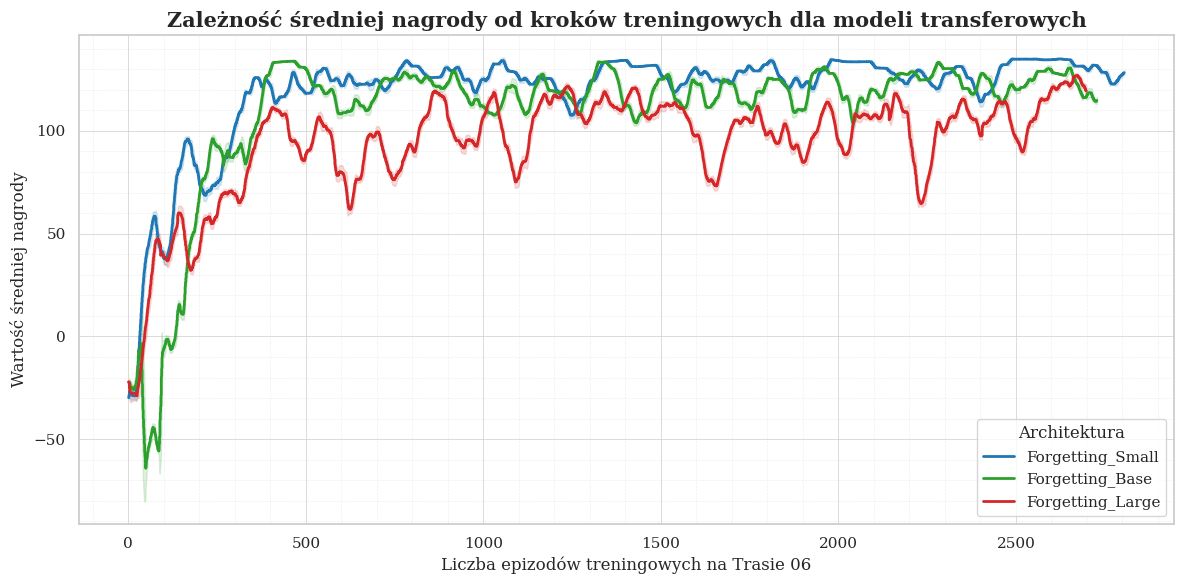

Zapisano wykres straty do: eval/plots\forgetting_transfer_shock_loss.png


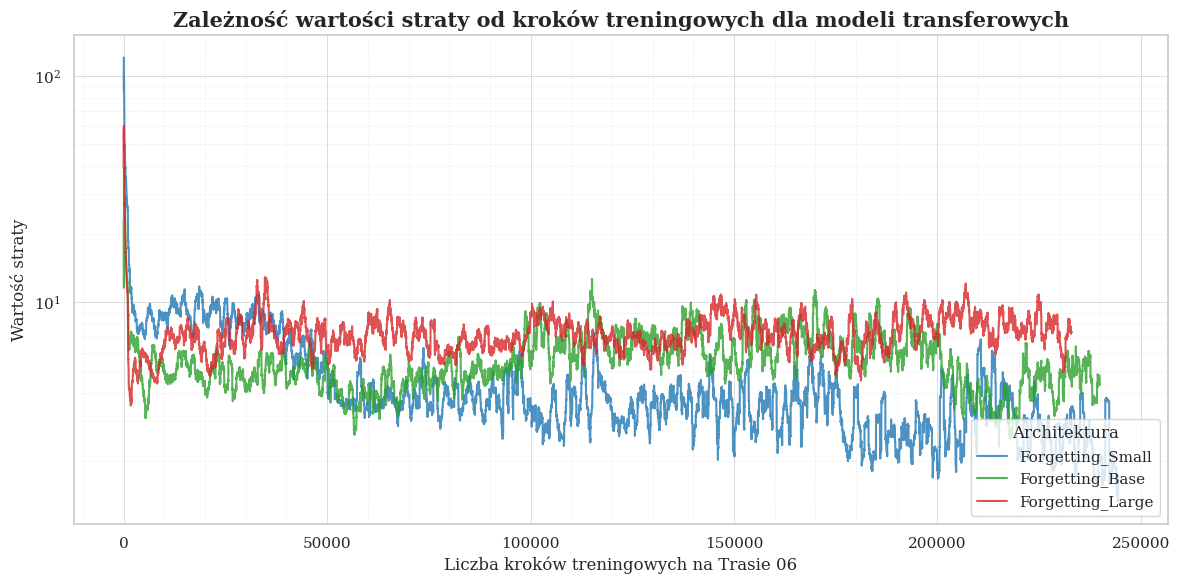

In [26]:
colors = {'Forgetting_Small': '#1f77b4', 'Forgetting_Base': '#2ca02c', 'Forgetting_Large': '#d62728'}
if not df_reward.empty:
    plt.figure(figsize=(12, 6))
    
    for model in ['Forgetting_Small', 'Forgetting_Base', 'Forgetting_Large']:
        subset = df_reward[df_reward['Model'] == model]
        if not subset.empty:
            plt.plot(subset['Step'], subset['Value_Smoothed'], label=model, color=colors.get(model, '#000'), linewidth=2)
            plt.fill_between(subset['Step'], 
                             subset['Value_Smoothed'] - subset['Value_Std'], 
                             subset['Value_Smoothed'] + subset['Value_Std'], 
                             color=colors.get(model, '#000'), alpha=0.15)

    plt.title('Zależność średniej nagrody od kroków treningowych dla modeli transferowych', fontsize=15, fontweight='bold')
    plt.xlabel('Liczba epizodów treningowych na Trasie 06', fontsize=12)
    plt.ylabel('Wartość średniej nagrody', fontsize=12)
    plt.legend(title="Architektura", loc="lower right")
    
    plt.minorticks_on()
    plt.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.7)
    plt.grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.3)
    plt.tight_layout()
    
    save_path = os.path.join(OUTPUT_DIR, 'forgetting_plasticity_reward.png')
    plt.savefig(save_path, dpi=300)
    print(f"Zapisano wykres nagrody do: {save_path}")
    plt.show()


if not df_loss.empty:
    plt.figure(figsize=(12, 6))
    
    for model in ['Forgetting_Small', 'Forgetting_Base', 'Forgetting_Large']:
        subset = df_loss[df_loss['Model'] == model]
        if not subset.empty:
            plt.plot(subset['Step'], subset['Value_Smoothed'], label=model, color=colors.get(model, '#000'), linewidth=1.5, alpha=0.8)

    plt.title('Zależność wartości straty od kroków treningowych dla modeli transferowych', fontsize=15, fontweight='bold')
    plt.xlabel('Liczba kroków treningowych na Trasie 06', fontsize=12)
    plt.ylabel('Wartość straty', fontsize=12)
    
    plt.yscale('log')
    plt.legend(title="Architektura", loc="lower right")
    
    plt.minorticks_on()
    plt.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.7)
    plt.grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.3)
    plt.tight_layout()
    
    save_path = os.path.join(OUTPUT_DIR, 'forgetting_transfer_shock_loss.png')
    plt.savefig(save_path, dpi=300)
    print(f"Zapisano wykres straty do: {save_path}")
    plt.show()

C:\Users\kkucz\AppData\Local\Temp\ipykernel_6208\1114802551.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_finished['Test_Name'] = pd.Categorical(df_finished['Test_Name'], categories=desired_order, ordered=True)


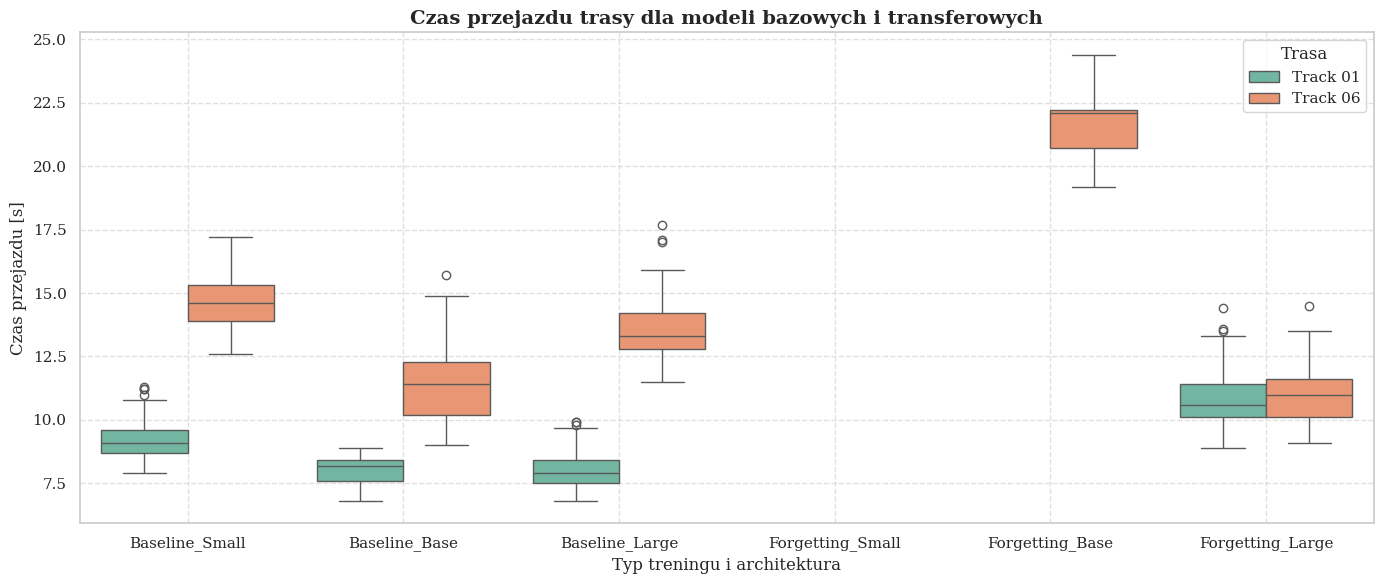

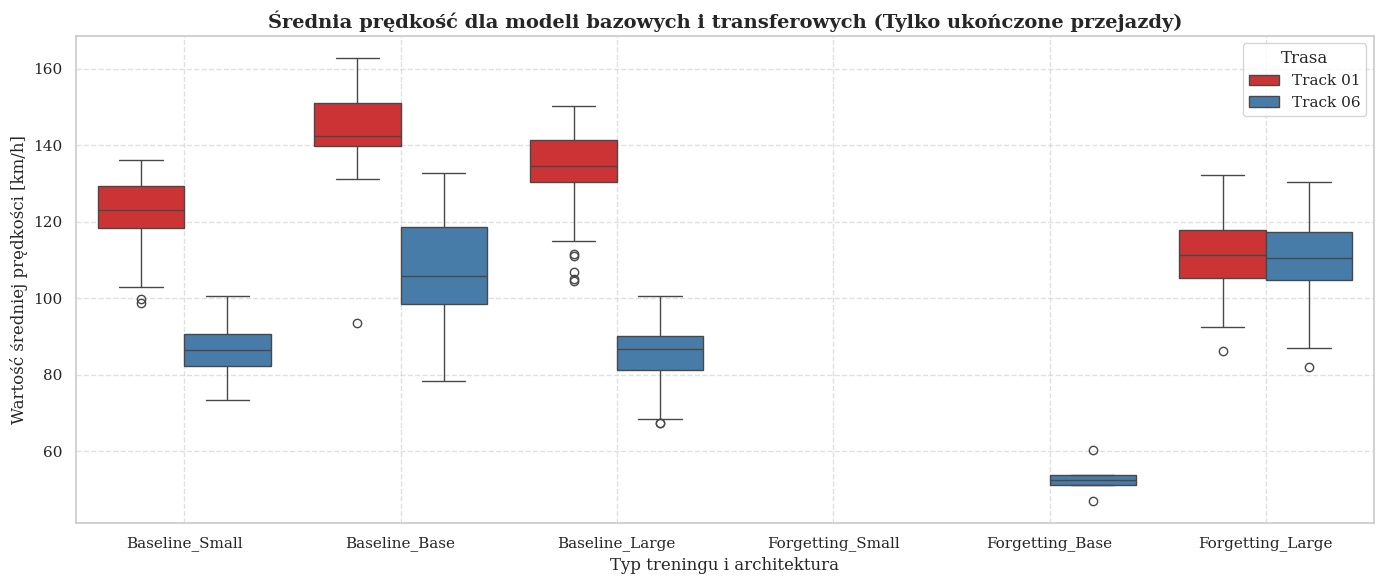

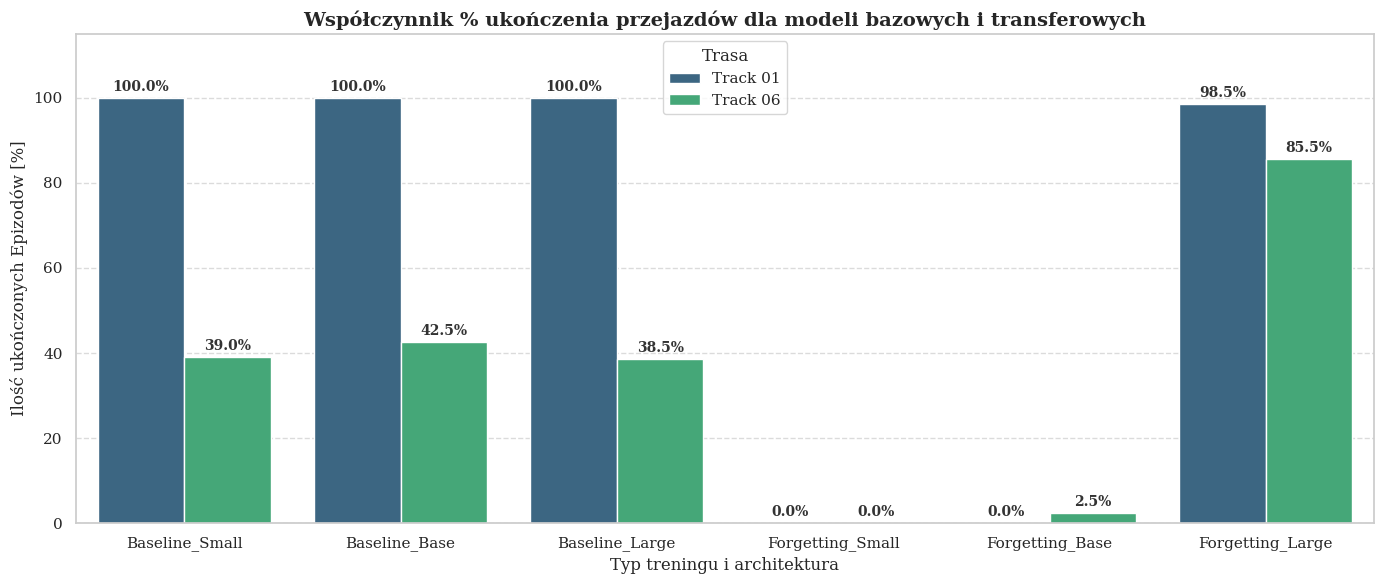

In [27]:
#4.4.2
TRACK_01_CSV = r"eval\raw_matrix_20260405_203355_track01.csv"
TRACK_06_CSV = r"eval\raw_matrix_20260410_203937_track06.csv"
OUTPUT_DIR = "eval/plots"

os.makedirs(OUTPUT_DIR, exist_ok=True)

df1 = pd.read_csv(TRACK_01_CSV)
df1['Track'] = 'Track 01'
df2 = pd.read_csv(TRACK_06_CSV)
df2['Track'] = 'Track 06'

df = pd.concat([df1, df2], ignore_index=True)

df = df[df['Test_Name'].str.contains("Baseline|Forgetting", case=False, na=False)]

TMRL_ENV_HZ = 10.0 
df['Real_InGame_Time'] = df['Steps'] / TMRL_ENV_HZ

df_finished = df[df['Status'] == 'WIN']


desired_order = [
    'Baseline_Small', 'Baseline_Base', 'Baseline_Large',
    'Forgetting_Small', 'Forgetting_Base', 'Forgetting_Large'
]

df_finished['Test_Name'] = pd.Categorical(df_finished['Test_Name'], categories=desired_order, ordered=True)
df['Test_Name'] = pd.Categorical(df['Test_Name'], categories=desired_order, ordered=True)


plt.figure(figsize=(14, 6))
ax1 = sns.boxplot(data=df_finished, x='Test_Name', y='Real_InGame_Time', hue='Track', palette='Set2')
plt.title('Czas przejazdu trasy dla modeli bazowych i transferowych', fontsize=14, fontweight='bold')
plt.xlabel('Typ treningu i architektura', fontsize=12)
plt.ylabel('Czas przejazdu [s]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
if ax1.legend_:
    ax1.legend_.set_title('Trasa')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_real_ingame_time_vs_forgetting.png'), dpi=300)
plt.show()


df_finished = df_finished.copy()
df_finished['Avg_Speed_kmh'] = df_finished['Avg_Speed'] * 3.6

plt.figure(figsize=(14, 6))
ax2 = sns.boxplot(data=df_finished, x='Test_Name', y='Avg_Speed_kmh', hue='Track', palette='Set1')
plt.title('Średnia prędkość dla modeli bazowych i transferowych (Tylko ukończone przejazdy)', fontsize=14, fontweight='bold')
plt.xlabel('Typ treningu i architektura', fontsize=12)
plt.ylabel('Wartość średniej prędkości [km/h]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
if ax2.legend_:
    ax2.legend_.set_title('Trasa')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_speed_vs_forgetting.png'), dpi=300)
plt.show()

completion_rates = df.groupby(['Track', 'Test_Name'], observed=False)['Status'].apply(lambda x: (x == 'WIN').mean() * 100).reset_index()

plt.figure(figsize=(14, 6))
ax3 = sns.barplot(data=completion_rates, x='Test_Name', y='Status', hue='Track', palette='viridis', order=desired_order)
plt.title('Współczynnik % ukończenia przejazdów dla modeli bazowych i transferowych', fontsize=14, fontweight='bold')
plt.xlabel('Typ treningu i architektura', fontsize=12)
plt.ylabel('Ilość ukończonych Epizodów [%]', fontsize=12)
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax3.containers:
    ax3.bar_label(
        container, 
        fmt='%.1f%%',
        label_type='edge',
        padding=3,
        fontsize=10, 
        fontweight='bold',
        color='#333333'
    )

if ax3.legend_:
    ax3.legend_.set_title('Trasa')
    
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_completion_rate_vs_forgetting.png'), dpi=300)
plt.show()

Zapisano wykres do: eval/plots\forgetting_amnesia_curve.png


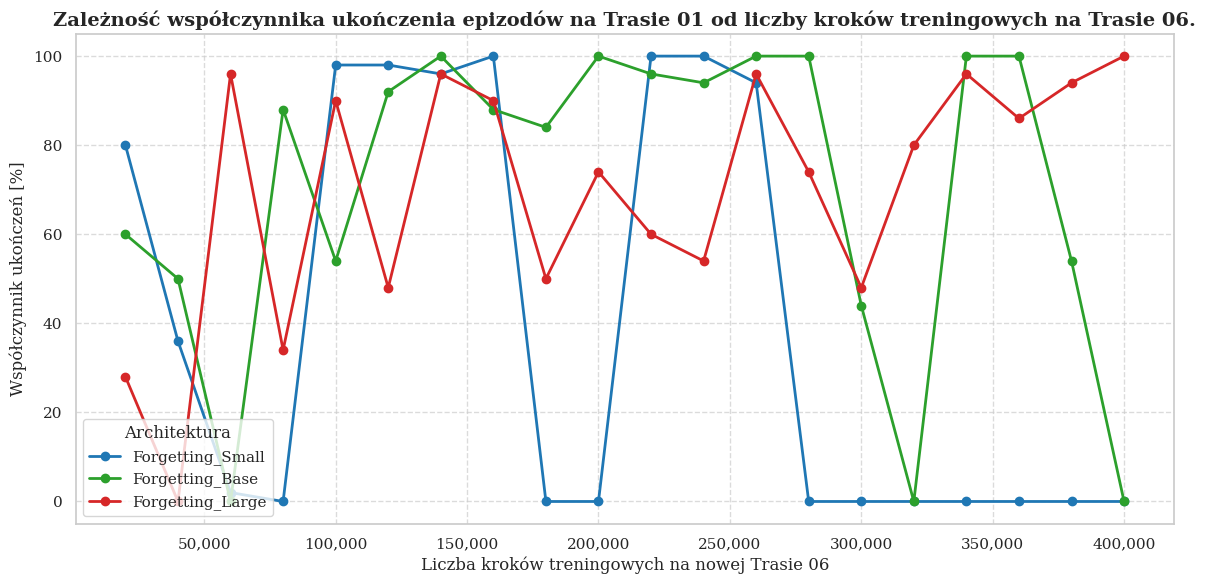

Zapisano mapę cieplną do: eval/plots\forgetting_instability_heatmap.png


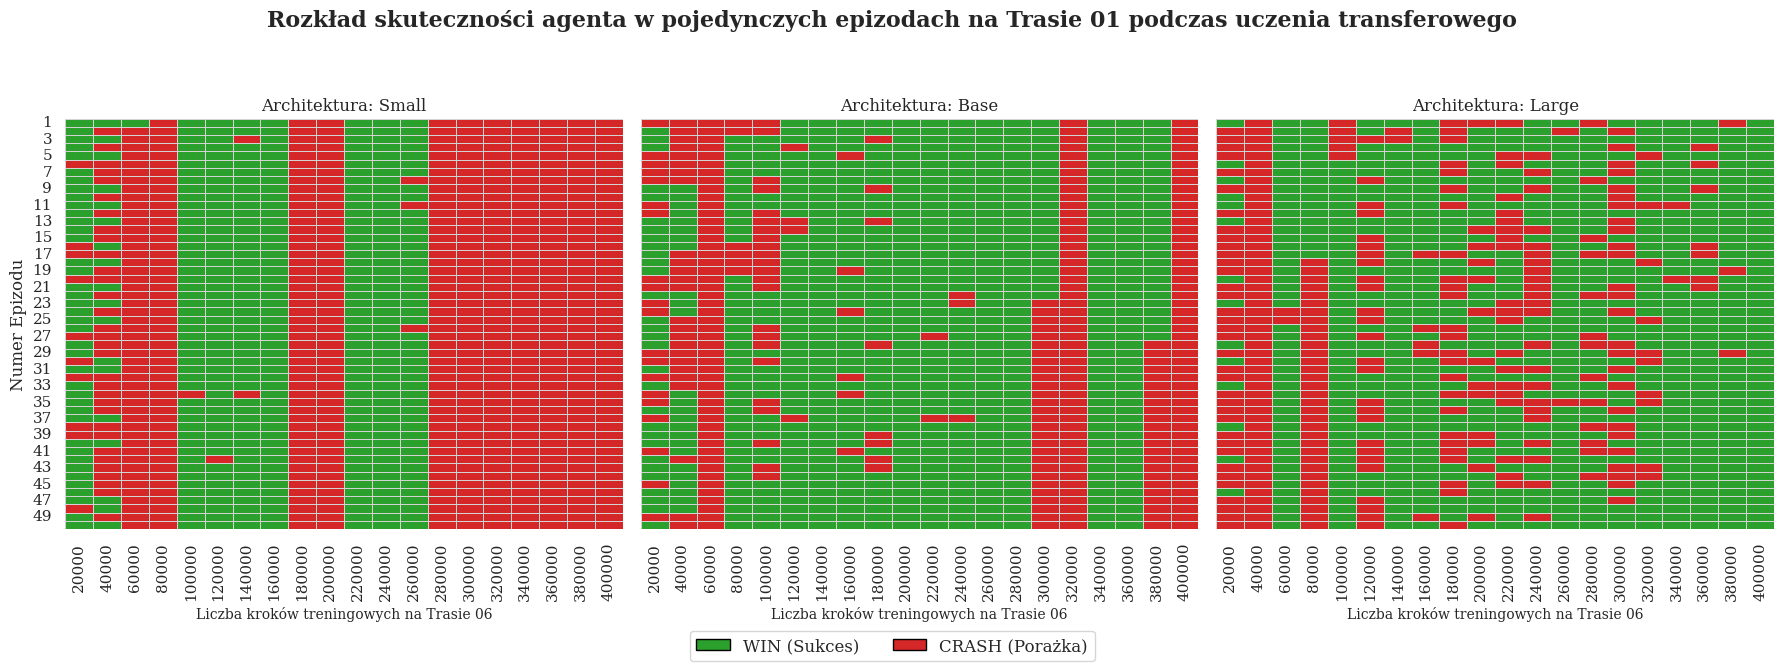

In [28]:
#4.4.3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.colors import ListedColormap

DYNAMIC_EVAL_CSV = r"eval\raw_dynamic_20260409_205246.csv"
OUTPUT_DIR = "eval/plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

try:
    df_dyn = pd.read_csv(DYNAMIC_EVAL_CSV)
    
    df_dyn['Test_Name'] = df_dyn['Test_Name'].str.replace(r'_\d+k', '', regex=True)

    completion_rates = df_dyn.groupby(['Test_Name', 'Checkpoint_Step'], observed=False)['Status'].apply(lambda x: (x == 'WIN').mean() * 100).reset_index()

    plt.figure(figsize=(12, 6))
    
    colors = {'Forgetting_Small': '#1f77b4', 'Forgetting_Base': '#2ca02c', 'Forgetting_Large': '#d62728'}
    
    for model_name in ['Forgetting_Small', 'Forgetting_Base', 'Forgetting_Large']:
        subset = completion_rates[completion_rates['Test_Name'] == model_name]
        subset = subset.sort_values(by='Checkpoint_Step')
        
        if not subset.empty:
            plt.plot(subset['Checkpoint_Step'], subset['Status'], marker='o', label=model_name, color=colors.get(model_name, '#000'), linewidth=2)

    plt.title('Zależność współczynnika ukończenia epizodów na Trasie 01 od liczby kroków treningowych na Trasie 06.', fontsize=14, fontweight='bold')
    plt.xlabel('Liczba kroków treningowych na nowej Trasie 06', fontsize=12)
    plt.ylabel('Współczynnik ukończeń [%]', fontsize=12)
    plt.ylim(-5, 105)
    
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    plt.legend(title="Architektura", loc="lower left")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'forgetting_amnesia_curve.png')
    plt.savefig(save_path, dpi=300)
    print(f"Zapisano wykres do: {save_path}")
    plt.show()

except FileNotFoundError:
    print(f"[ERROR] Nie znaleziono pliku: {DYNAMIC_EVAL_CSV}")
except Exception as e:
    print(f"Wystąpił błąd: {e}")

try:
    df_dyn = pd.read_csv(DYNAMIC_EVAL_CSV)
    df_dyn['Test_Name'] = df_dyn['Test_Name'].str.replace(r'_\d+k', '', regex=True)
    
    df_dyn['Success_Int'] = (df_dyn['Status'] == 'WIN').astype(int)

    models = ['Forgetting_Small', 'Forgetting_Base', 'Forgetting_Large']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    fig.suptitle('Rozkład skuteczności agenta w pojedynczych epizodach na Trasie 01 podczas uczenia transferowego', fontsize=16, fontweight='bold', y=1.05)

    cmap = ListedColormap(['#d62728', '#2ca02c'])

    for idx, model_name in enumerate(models):
        ax = axes[idx]
        subset = df_dyn[df_dyn['Test_Name'] == model_name]
        
        if subset.empty:
            ax.set_title(f'{model_name} (Brak Danych)')
            continue

        heatmap_data = subset.pivot(index='Episode', columns='Checkpoint_Step', values='Success_Int')
        
        sns.heatmap(heatmap_data, ax=ax, cmap=cmap, cbar=False, linewidths=.5, linecolor='lightgray')
        
        ax.set_title(f'Architektura: {model_name.replace("Forgetting_", "")}', fontsize=12)
        ax.set_xlabel('Liczba kroków treningowych na Trasie 06', fontsize=10)
        if idx == 0:
            ax.set_ylabel('Numer Epizodu')
        else:
            ax.set_ylabel('')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2ca02c', edgecolor='black', label='WIN (Sukces)'),
                       Patch(facecolor='#d62728', edgecolor='black', label='CRASH (Porażka)')]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=12)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'forgetting_instability_heatmap.png')
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"Zapisano mapę cieplną do: {save_path}")
    plt.show()

except FileNotFoundError:
    print(f"[ERROR] Nie znaleziono pliku: {DYNAMIC_EVAL_CSV}")
except Exception as e:
    print(f"Wystąpił błąd: {e}")